# 🌸 Train – Huấn luyện mô hình Iris Dataset

**Môn:** Machine Learning  
**Bài toán:** Multiclass Classification – Phân loại 3 loại hoa Iris  
**Dataset:** iris.csv  
**4 features | 150 mẫu | 3 classes**

## Bước 5: Khởi tạo thí nghiệm

In [1]:
# ── Khai báo thư viện ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection    import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.svm                import SVC
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import (RandomForestClassifier, AdaBoostClassifier,
                                        GradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network     import MLPClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score,
                                        confusion_matrix, ConfusionMatrixDisplay,
                                        classification_report, RocCurveDisplay)

# ── Tham số thực nghiệm ─────────────────────────────────
# ============================================================
# NHẬP TÊN DATA DÙNG ĐỂ TRAIN (không có đuôi .csv)
TRAIN_DATA_NAME = 'iris'   # bộ dữ liệu dùng để train (bắt buộc đã được eda rồi)
# ============================================================

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..')) \
            if os.path.basename(os.getcwd()) == 'prj' \
            else os.getcwd()                             # thư mục gốc của project

EXP_DIR   = os.path.join(BASE_DIR, 'exps_')             # thư mục chứa file CSV từ EDA
MODEL_DIR = os.path.join(BASE_DIR, 'model', TRAIN_DATA_NAME)  # thư mục lưu model .pkl
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_LOG    = os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_train_log.xlsx')  # file ghi kết quả
N_SPLITS     = 5            # chia data train thành 5 phần bằng nhau (K-Fold)
RANDOM_STATE = 42           # seed cố định – kết quả giống nhau mỗi lần chạy
SCORING      = 'accuracy'   # tiêu chí đánh giá trong K-Fold

# Trọng số cho Composite score = w_acc*Acc + w_f1*F1 + w_auc*AUC
W_ACC = 0.4
W_F1  = 0.3
W_AUC = 0.3

# File dữ liệu từ EDA – mỗi scaler có 1 cặp (train, test)
FILES = {
    'raw':      (os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_train_raw.csv'),
                 os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_test_raw.csv')),
    'minmax':   (os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_train_minmax.csv'),
                 os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_test_minmax.csv')),
    'standard': (os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_train_standard.csv'),
                 os.path.join(EXP_DIR, f'{TRAIN_DATA_NAME}_test_standard.csv')),
}

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ Khai báo thư viện và tham số xong!')
print(f'   Thời gian       : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'   TRAIN_DATA_NAME : {TRAIN_DATA_NAME}')
print(f'   BASE_DIR        : {BASE_DIR}')
print(f'   K-Fold          : {N_SPLITS} folds (Stratified)')
print(f'   Scoring         : {SCORING}')
print(f'   Model folder    : model/{TRAIN_DATA_NAME}/')

✅ Khai báo thư viện và tham số xong!
   Thời gian       : 2026-04-03 14:22:24
   TRAIN_DATA_NAME : iris
   BASE_DIR        : D:\final-project-CSTTNT-\irisClassification
   K-Fold          : 5 folds (Stratified)
   Scoring         : accuracy
   Model folder    : model/iris/


File dữ liệu được đọc từ `exps_/` — kết quả của bước EDA — theo từng loại chuẩn hóa.
Biến `FILES` ánh xạ tên scaler với cặp đường dẫn `(train, test)` để vòng lặp
sau này duyệt qua cả ba phiên bản một cách đồng nhất.

## Bước 6: Dữ liệu kiểm nghiệm

Hàm `load_data` đọc file CSV và tách thành ma trận feature `X` và vector nhãn `y`.
Cột cuối cùng luôn là nhãn — quy ước này được giữ nhất quán từ bước lưu file ở EDA.

In [2]:
def load_data(train_path, test_path):
    train   = pd.read_csv(train_path)
    test    = pd.read_csv(test_path)
    X_train = train.iloc[:, :-1].values
    y_train = train.iloc[:, -1].values
    X_test  = test.iloc[:, :-1].values
    y_test  = test.iloc[:, -1].values
    return X_train, X_test, y_train, y_test

print('=== KIỂM TRA DỮ LIỆU ===')
for scaler_name, (train_path, test_path) in FILES.items():
    X_tr, X_te, y_tr, y_te = load_data(train_path, test_path)
    print(f'[{scaler_name:8s}] Train: {X_tr.shape} | Test: {X_te.shape} | Classes: {np.unique(y_tr)}')

print('\n✅ Dữ liệu kiểm nghiệm sẵn sàng!')
print(f'   Chiến lược hold-out : Train 70% / Test 30%')
print(f'   Chiến lược k-fold   : {N_SPLITS}-fold Stratified trên tập Train')

=== KIỂM TRA DỮ LIỆU ===
[raw     ] Train: (105, 4) | Test: (45, 4) | Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
[minmax  ] Train: (105, 4) | Test: (45, 4) | Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
[standard] Train: (105, 4) | Test: (45, 4) | Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

✅ Dữ liệu kiểm nghiệm sẵn sàng!
   Chiến lược hold-out : Train 70% / Test 30%
   Chiến lược k-fold   : 5-fold Stratified trên tập Train


## Bước 7: Lượng giá thuật toán
### 7.1 Baselines – 10 model tham số mặc định

Mười model baseline được khởi tạo với tham số mặc định, bao gồm các họ thuật toán
khác nhau: dựa khoảng cách (kNN), xác suất (Naive Bayes, Logistic Regression),
SVM, cây quyết định, ensemble (Random Forest, AdaBoost, Gradient Boosting),
phân tích tuyến tính (LDA) và mạng nơ-ron (MLP).

Đánh giá bằng Stratified K-Fold để đảm bảo mỗi fold đều có đủ mẫu từng lớp,
tránh trường hợp một fold thiếu hẳn một lớp khi dữ liệu nhỏ.

In [3]:
def get_baseline_models():
    return [
        ('kNN',               KNeighborsClassifier()),
        ('Naive Bayes',       GaussianNB()),
        ('SVM',               SVC(probability=True, random_state=RANDOM_STATE)),
        ('Decision Tree',     DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ('Random Forest',     RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('Extra Trees',       ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('AdaBoost',          AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('LDA',               LinearDiscriminantAnalysis()),
        ('MLP',               MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500,
                                            random_state=RANDOM_STATE)),
        ('Logistic Reg.',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
baseline_results = []

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, _, y_train, _ = load_data(train_path, test_path)
    classes = np.unique(y_train)
    is_binary = len(classes) == 2
    print(f'\n📊 [{scaler_name.upper()}] Baseline – {N_SPLITS}-Fold CV:')
    print(f'  {"Model":<22} {"Acc":>8} {"F1":>8} {"AUC":>8} {"Composite":>10}')
    print('  ' + '-' * 60)
    for name, model in get_baseline_models():
        acc_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
        f1_scores  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1_weighted')
        auc_scores = cross_val_score(model, X_train, y_train, cv=skf,
                                     scoring='roc_auc' if is_binary else 'roc_auc_ovr_weighted')
        composite = round(W_ACC*acc_scores.mean() + W_F1*f1_scores.mean() + W_AUC*auc_scores.mean(), 4)
        baseline_results.append({
            'Scaler'   : scaler_name, 'Model': name, 'Loại': 'Baseline',
            'Accuracy' : round(acc_scores.mean(), 4), 'Acc Std': round(acc_scores.std(), 4),
            'F1'       : round(f1_scores.mean(),  4), 'F1 Std' : round(f1_scores.std(),  4),
            'ROC_AUC'  : round(auc_scores.mean(), 4), 'AUC Std': round(auc_scores.std(), 4),
            'Params'   : 'default', 'Composite': composite,
        })
        print(f'  {name:<22} {acc_scores.mean():>8.4f} {f1_scores.mean():>8.4f} {auc_scores.mean():>8.4f} {composite:>10.4f}')

df_baseline = pd.DataFrame(baseline_results)
print('\n✅ Baseline xong!')


📊 [RAW] Baseline – 5-Fold CV:
  Model                       Acc       F1      AUC  Composite
  ------------------------------------------------------------
  kNN                      0.9619   0.9618   0.9966     0.9723
  Naive Bayes              0.9810   0.9809   0.9932     0.9846
  SVM                      0.9619   0.9618   0.9986     0.9729
  Decision Tree            0.9333   0.9328   0.9500     0.9382
  Random Forest            0.9524   0.9519   0.9980     0.9659
  Extra Trees              0.9714   0.9714   0.9973     0.9792
  AdaBoost                 0.9524   0.9519   0.9918     0.9641
  Gradient Boosting        0.9619   0.9614   0.9908     0.9704
  LDA                      0.9714   0.9714   0.9973     0.9792
  MLP                      0.9714   0.9713   0.9986     0.9795
  Logistic Reg.            0.9619   0.9618   0.9973     0.9725

📊 [MINMAX] Baseline – 5-Fold CV:
  Model                       Acc       F1      AUC  Composite
  ---------------------------------------------------

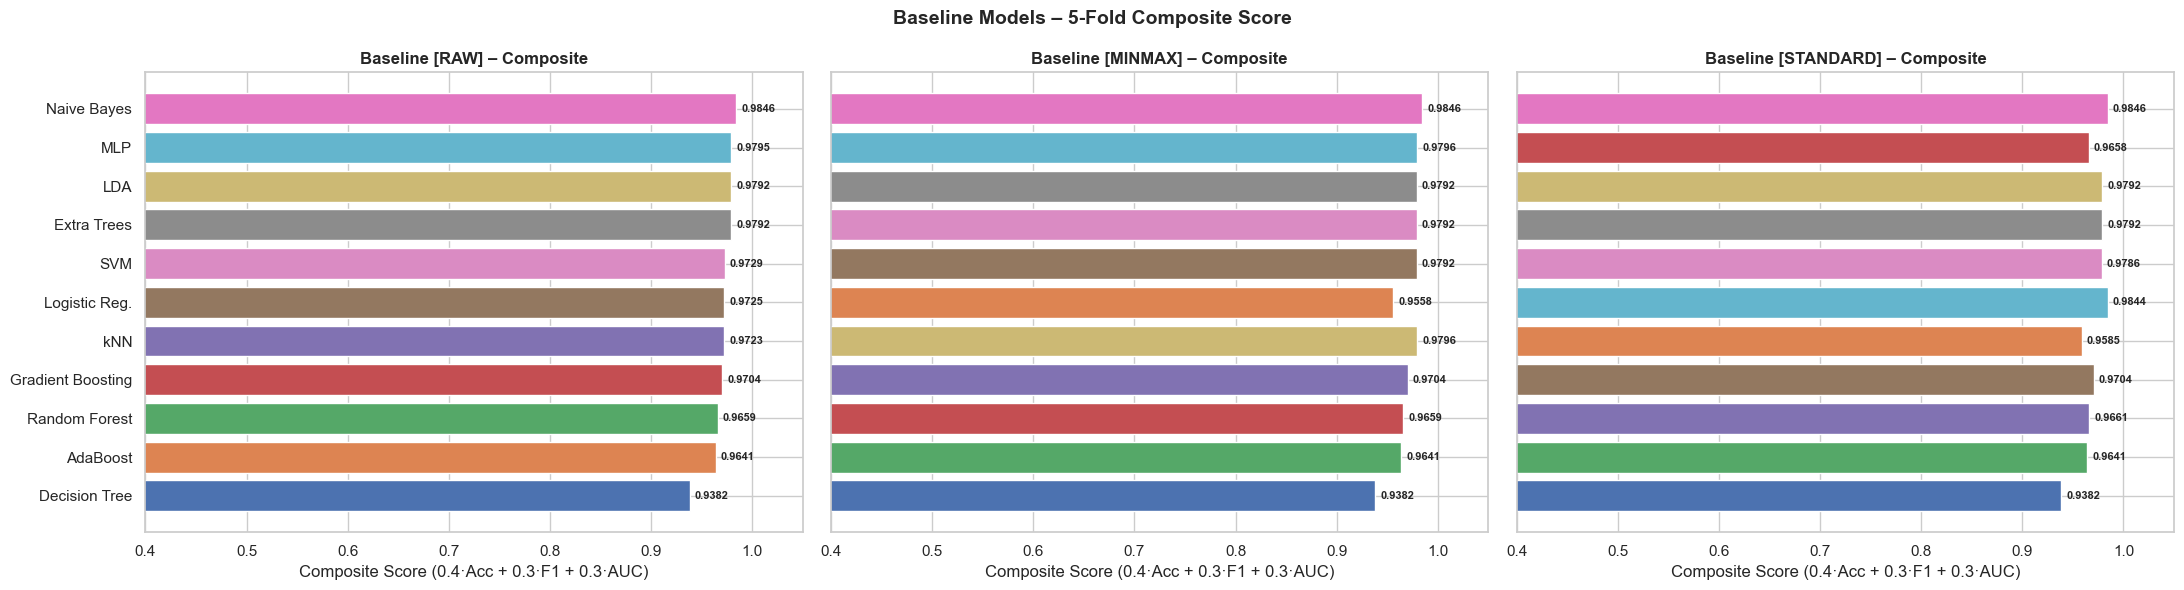

In [4]:
# Biểu đồ Baseline – trục x là Composite score
colors_bar = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
              '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD','#E377C2']

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for idx_ax, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_baseline[df_baseline['Scaler'] == scaler_name].sort_values('Composite')
    bars   = axes[idx_ax].barh(subset['Model'], subset['Composite'],
                               color=colors_bar[:len(subset)], edgecolor='white')
    axes[idx_ax].set_title(f'Baseline [{scaler_name.upper()}] – Composite', fontweight='bold', fontsize=12)
    axes[idx_ax].set_xlabel('Composite Score (0.4·Acc + 0.3·F1 + 0.3·AUC)')
    axes[idx_ax].set_xlim(0.4, 1.05)
    for bar, row in zip(bars, subset.itertuples()):
        axes[idx_ax].text(row.Composite + 0.005, bar.get_y() + bar.get_height()/2,
                          f'{row.Composite:.4f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle(f'Baseline Models – {N_SPLITS}-Fold Composite Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_baseline.png'), bbox_inches='tight')
plt.show()

### 7.2 Tinh chỉnh tham số – SVM & Random Forest

Sau khi xác định được hai model triển vọng nhất từ baseline (SVM và Random Forest),
GridSearchCV duyệt qua lưới tham số để tìm bộ tham số cho độ chính xác K-Fold cao nhất.
Quá trình này vẫn dùng `cv=skf` và chỉ chạy trên tập train — tập test chưa được chạm vào.

In [5]:
SVM_PARAMS = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
              'kernel': ['linear', 'rbf']}
RF_PARAMS  = {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10],
              'min_samples_split': [2, 4]}
GB_PARAMS  = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1],
              'max_depth': [3, 5]}
KNN_PARAMS = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
LR_PARAMS  = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}

TUNED_GRIDS = [
    ('SVM (tuned)',               SVC(probability=True, random_state=RANDOM_STATE),    SVM_PARAMS),
    ('Random Forest (tuned)',     RandomForestClassifier(random_state=RANDOM_STATE),   RF_PARAMS),
    ('Gradient Boosting (tuned)', GradientBoostingClassifier(random_state=RANDOM_STATE), GB_PARAMS),
    ('kNN tuned',                 KNeighborsClassifier(),                               KNN_PARAMS),
    ('Logistic Reg. tuned',       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), LR_PARAMS),
]

tuned_results   = []
best_estimators = {}  # {scaler: {name: estimator}}

for scaler_name, (train_path, test_path) in FILES.items():
    X_train, _, y_train, _ = load_data(train_path, test_path)
    is_binary = len(np.unique(y_train)) == 2
    best_estimators[scaler_name] = {}
    print(f'\n🔧 [{scaler_name.upper()}] Tinh chỉnh tham số:')

    for tune_name, base_model, param_grid in TUNED_GRIDS:
        grid = GridSearchCV(base_model, param_grid, cv=skf,
                            scoring='roc_auc' if is_binary else 'roc_auc_ovr_weighted',
                            n_jobs=-1)
        grid.fit(X_train, y_train)

        # Tính lại Composite trên các fold tốt nhất
        best_est = grid.best_estimator_
        acc_s = cross_val_score(best_est, X_train, y_train, cv=skf, scoring='accuracy')
        f1_s  = cross_val_score(best_est, X_train, y_train, cv=skf, scoring='f1_weighted')
        auc_s = cross_val_score(best_est, X_train, y_train, cv=skf,
                                scoring='roc_auc' if is_binary else 'roc_auc_ovr_weighted')
        composite = round(W_ACC*acc_s.mean() + W_F1*f1_s.mean() + W_AUC*auc_s.mean(), 4)

        tuned_results.append({
            'Scaler'   : scaler_name, 'Model': tune_name, 'Loại': 'Tuned',
            'Accuracy' : round(acc_s.mean(), 4), 'Acc Std': round(acc_s.std(), 4),
            'F1'       : round(f1_s.mean(),  4), 'F1 Std' : round(f1_s.std(),  4),
            'ROC_AUC'  : round(auc_s.mean(), 4), 'AUC Std': round(auc_s.std(), 4),
            'Params'   : str(grid.best_params_), 'Composite': composite,
        })
        best_estimators[scaler_name][tune_name] = best_est
        print(f'  {tune_name:<28} Composite={composite:.4f} | {grid.best_params_}')

df_tuned = pd.DataFrame(tuned_results)
print('\n✅ Tinh chỉnh xong!')


🔧 [RAW] Tinh chỉnh tham số:
  SVM (tuned)                  Composite=0.9729 | {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  Random Forest (tuned)        Composite=0.9661 | {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Gradient Boosting (tuned)    Composite=0.9709 | {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
  kNN tuned                    Composite=0.9862 | {'n_neighbors': 9, 'weights': 'distance'}
  Logistic Reg. tuned          Composite=0.9862 | {'C': 10, 'solver': 'lbfgs'}

🔧 [MINMAX] Tinh chỉnh tham số:
  SVM (tuned)                  Composite=0.9662 | {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  Random Forest (tuned)        Composite=0.9661 | {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Gradient Boosting (tuned)    Composite=0.9709 | {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
  kNN tuned                    Composite=0.9796 | {'n_neighbors': 5, 'weights': 'uniform'}
  Logistic Reg. tuned      

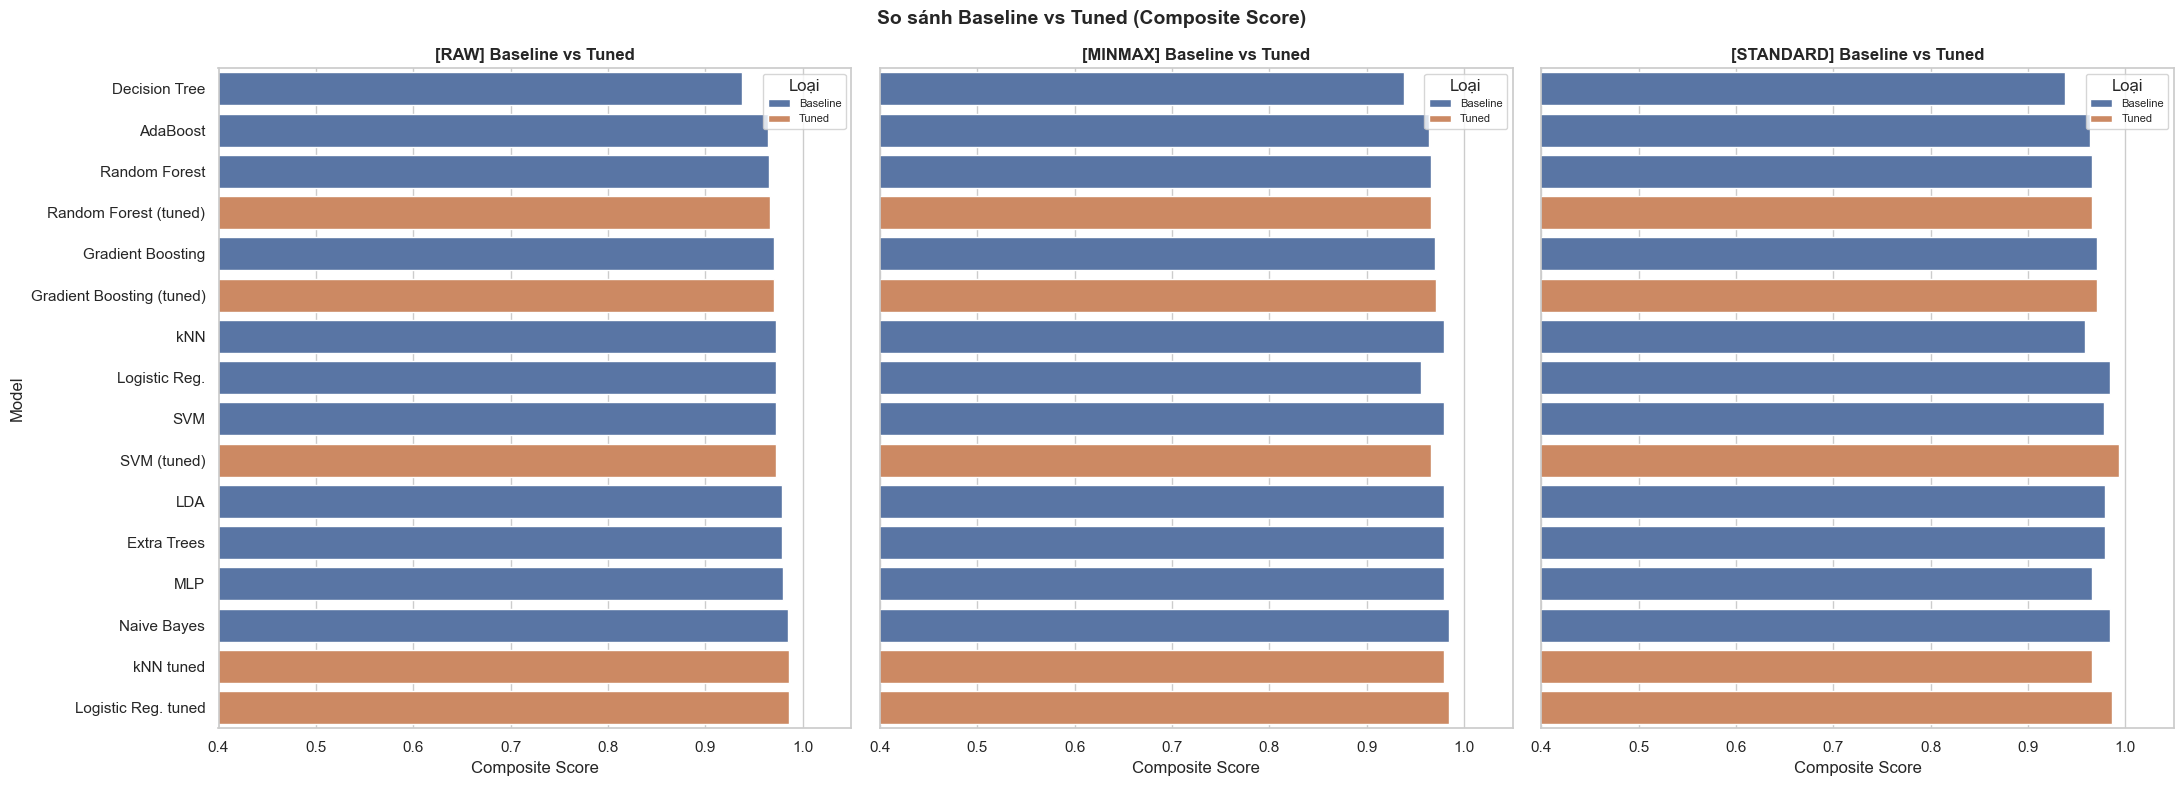

In [6]:
# Gộp tất cả kết quả và sắp xếp theo Composite
df_kfold_all = pd.concat([df_baseline, df_tuned], ignore_index=True)
df_kfold_all = df_kfold_all.sort_values('Composite', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
palette = {'Baseline': '#4C72B0', 'Tuned': '#DD8452'}

for idx_ax, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_kfold_all[df_kfold_all['Scaler'] == scaler_name].copy()
    subset = subset.sort_values('Composite')
    sns.barplot(data=subset, x='Composite', y='Model', hue='Loại',
                palette=palette, ax=axes[idx_ax], orient='h')
    axes[idx_ax].set_title(f'[{scaler_name.upper()}] Baseline vs Tuned', fontweight='bold')
    axes[idx_ax].set_xlabel('Composite Score')
    axes[idx_ax].set_xlim(0.4, 1.05)
    axes[idx_ax].legend(title='Loại', fontsize=8)

plt.suptitle('So sánh Baseline vs Tuned (Composite Score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_baseline_vs_tuned.png'), bbox_inches='tight')
plt.show()

## Bước 8: Train toàn bộ & Lưu model

Sau khi hoàn tất K-Fold, tất cả mô hình được fit lại trên **toàn bộ tập train**
để tạo phiên bản cuối cùng cho bước test.

Notebook vẫn hiển thị **top 2 model** theo Composite score để đối chiếu ngay trong bước train,
nhưng chỉ export **duy nhất 1 bundle**:
- `iris__best_model.pkl` — chứa `model`, `model_name`, `scaler_name`, `cv_metrics`

Model đứng hạng 2 chỉ dùng để tham chiếu trong báo cáo, không được mang sang `03_test.ipynb`.


In [7]:
# Fit toàn bộ model trên tập train đầy đủ (không chia fold)
# So sánh top-2 ngay trong notebook train, nhưng chỉ lưu 1 best bundle duy nhất
all_estimators = {}   # {scaler__name: estimator}

for scaler_name, (train_path, _) in FILES.items():
    train_df = pd.read_csv(train_path)
    X_train  = train_df.iloc[:, :-1].values
    y_train  = train_df.iloc[:, -1].values

    # Fit baseline
    for name, model in get_baseline_models():
        model.fit(X_train, y_train)
        all_estimators[f'{scaler_name}__{name}'] = model

    # Fit tuned
    for tune_name, estimator in best_estimators[scaler_name].items():
        estimator.fit(X_train, y_train)
        all_estimators[f'{scaler_name}__{tune_name}'] = estimator

# ── Chọn Top 2 theo Composite score ──────────────────────────
top2 = []
for _, row in df_kfold_all.iterrows():
    key = f'{row["Scaler"]}__{row["Model"]}'
    if key in all_estimators:
        top2.append({
            'rank'     : len(top2) + 1,
            'name'     : row['Model'],
            'scaler'   : row['Scaler'],
            'accuracy' : row['Accuracy'],
            'f1'       : row['F1'],
            'roc_auc'  : row['ROC_AUC'],
            'composite': row['Composite'],
            'est'      : all_estimators[key],
        })
    if len(top2) == 2:
        break

print('\n📊 So sánh Top 2 model (K-Fold):')
print(f'  {"":4} {"Model":<28} {"Scaler":<10} {"Acc":>7} {"F1":>7} {"AUC":>7} {"Composite":>10}')
print('  ' + '-' * 75)
for m in top2:
    tag = '← dùng để TEST' if m['rank'] == 1 else '← tham chiếu'
    print(f'  #{m["rank"]:<3} {m["name"]:<28} {m["scaler"]:<10} {m["accuracy"]:>7.4f} {m["f1"]:>7.4f} {m["roc_auc"]:>7.4f} {m["composite"]:>10.4f}  {tag}')

best_bundle = {
    'model'      : top2[0]['est'],
    'model_name' : top2[0]['name'],
    'scaler_name': top2[0]['scaler'],
    'cv_metrics' : {
        'Accuracy' : float(top2[0]['accuracy']),
        'F1'       : float(top2[0]['f1']),
        'ROC_AUC'  : float(top2[0]['roc_auc']),
        'Composite': float(top2[0]['composite']),
    },
}

# ── Lưu DUY NHẤT model #1 ra pkl ──────────────────────────────
best_path = os.path.join(MODEL_DIR, f'{TRAIN_DATA_NAME}__best_model.pkl')
with open(best_path, 'wb') as f:
    pickle.dump(best_bundle, f)
print(f'\n💾 Đã lưu: {os.path.basename(best_path)}')
print(f'   Model : {top2[0]["name"]} [{top2[0]["scaler"]}]')
print('   Bundle: model + model_name + scaler_name + cv_metrics')



📊 So sánh Top 2 model (K-Fold):
       Model                        Scaler         Acc      F1     AUC  Composite
  ---------------------------------------------------------------------------
  #1   SVM (tuned)                  standard    0.9905  0.9904  1.0000     0.9933  ← dùng để TEST
  #2   Logistic Reg. tuned          standard    0.9810  0.9809  0.9986     0.9862  ← tham chiếu

💾 Đã lưu: iris__best_model.pkl
   Model : SVM (tuned) [standard]
   Bundle: model + model_name + scaler_name + cv_metrics


## Bước 9: Ghi train_log.xlsx

File `train_log.xlsx` ghi lại toàn bộ kết quả K-Fold của lần chạy hiện tại.
Nếu file đã tồn tại, lịch sử các lần chạy trước được giữ nguyên trong sheet `Lich_su_chay`
và kết quả mới được nối thêm vào — không ghi đè lịch sử cũ.
Ba sheet còn lại (`Baseline_KFold`, `Tuned_KFold`, `Tat_ca_KFold`) ghi đè mỗi lần chạy.

In [8]:
os.makedirs(MODEL_DIR, exist_ok=True)

# Lịch sử chạy – khớp với cấu trúc mẫu train_log.xlsx
df_exp_info = pd.DataFrame([{
    'Thời gian'   : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Dataset'     : TRAIN_DATA_NAME,
    'K-Fold'      : N_SPLITS,
    'Best model'  : top2[0]['name'],
    'Best scaler' : top2[0]['scaler'],
    'Accuracy'    : top2[0]['accuracy'],
    'F1'          : top2[0]['f1'],
    'ROC_AUC'     : top2[0]['roc_auc'],
    'Composite'   : top2[0]['composite'],
    'Model folder': MODEL_DIR,
}])

# Nối lịch sử – không ghi đè các lần chạy cũ
if os.path.exists(TRAIN_LOG):
    try:
        df_old     = pd.read_excel(TRAIN_LOG, sheet_name='Lich_su_chay')
        df_history = pd.concat([df_old, df_exp_info], ignore_index=True)
        is_new     = False
    except Exception:
        df_history = df_exp_info
        is_new     = True
else:
    df_history = df_exp_info
    is_new     = True

# Sheet Best_model – chỉ giữ metrics của model tốt nhất lần chạy này
df_best = pd.DataFrame([{
    'accuracy' : top2[0]['accuracy'],
    'f1'       : top2[0]['f1'],
    'roc_auc'  : top2[0]['roc_auc'],
    'composite': top2[0]['composite'],
}])

# Sheet Tat_ca_model – toàn bộ xếp hạng theo Composite
df_all_sorted = df_kfold_all[['Scaler','Model','Loại','Accuracy','Acc Std',
                               'F1','F1 Std','ROC_AUC','AUC Std','Params','Composite']] \
                .sort_values('Composite', ascending=False).reset_index(drop=True)

with pd.ExcelWriter(TRAIN_LOG, engine='openpyxl', mode='w') as writer:
    df_history.to_excel(writer,   sheet_name='Lich_su_chay',  index=False)
    df_baseline[['Scaler','Model','Loại','Accuracy','Acc Std','F1','F1 Std',
                 'ROC_AUC','AUC Std','Params','Composite']].to_excel(
        writer, sheet_name='Baseline', index=False)
    df_tuned[['Scaler','Model','Loại','Accuracy','Acc Std','F1','F1 Std',
              'ROC_AUC','AUC Std','Params','Composite']].to_excel(
        writer, sheet_name='Tuned', index=False)
    df_all_sorted.to_excel(writer, sheet_name='Tat_ca_model', index=False)
    df_best.to_excel(writer,       sheet_name='Best_model',   index=False)

label = '🆕 Tạo file mới' if is_new else '➕ Cập nhật file'
print(f'{label}: {os.path.basename(TRAIN_LOG)}')
print(f'⏱  Thời gian ghi: {df_exp_info["Thời gian"].iloc[0]}')
from openpyxl import load_workbook as _lw
_wb = _lw(TRAIN_LOG)
print('📋 Cấu trúc (5 sheets):')
for i, sh in enumerate(_wb.sheetnames):
    print(f'   Sheet {i+1}: {sh}')
_wb.close()

➕ Cập nhật file: iris_train_log.xlsx
⏱  Thời gian ghi: 2026-04-03 14:24:12
📋 Cấu trúc (5 sheets):
   Sheet 1: Lich_su_chay
   Sheet 2: Baseline
   Sheet 3: Tuned
   Sheet 4: Tat_ca_model
   Sheet 5: Best_model


## Tổng kết thực nghiệm

In [9]:
print('=' * 65)
print('TỔNG KẾT THỰC NGHIỆM - ' + TRAIN_DATA_NAME.upper())
print('=' * 65)
print(f'⏱  Thời gian hoàn thành: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'\n📌 Cấu hình:')
print(f'   K-Fold    : {N_SPLITS} folds (Stratified)')
print(f'   Composite : {W_ACC}·Acc + {W_F1}·F1 + {W_AUC}·AUC')
print(f'   Scalers   : raw, minmax, standard')
print(f'\n📊 Top 2 model (theo Composite score):')
print(f'  {"":4} {"Model":<28} {"Scaler":<10} {"Acc":>7} {"F1":>7} {"AUC":>7} {"Composite":>10}')
print('  ' + '-' * 75)
for m in top2:
    tag = '← sẽ dùng test' if m['rank'] == 1 else '← tham chiếu'
    print(f'  #{m["rank"]:<3} {m["name"]:<28} {m["scaler"]:<10} {m["accuracy"]:>7.4f} {m["f1"]:>7.4f} {m["roc_auc"]:>7.4f} {m["composite"]:>10.4f}  {tag}')
print(f'\n💾 File pkl xuất ra (1 file duy nhất):')
print(f'   {TRAIN_DATA_NAME}__best_model.pkl')
print(f'\n📁 Log: {os.path.basename(TRAIN_LOG)}')
print('=' * 65)
print('➡  Bước tiếp theo: chạy 03_test.ipynb')
print(f'   TRAIN_DATA_NAME = {TRAIN_DATA_NAME!r}')
print(f'   TEST_DATA_NAME  = ???')

TỔNG KẾT THỰC NGHIỆM - IRIS
⏱  Thời gian hoàn thành: 2026-04-03 14:24:12

📌 Cấu hình:
   K-Fold    : 5 folds (Stratified)
   Composite : 0.4·Acc + 0.3·F1 + 0.3·AUC
   Scalers   : raw, minmax, standard

📊 Top 2 model (theo Composite score):
       Model                        Scaler         Acc      F1     AUC  Composite
  ---------------------------------------------------------------------------
  #1   SVM (tuned)                  standard    0.9905  0.9904  1.0000     0.9933  ← sẽ dùng test
  #2   Logistic Reg. tuned          standard    0.9810  0.9809  0.9986     0.9862  ← tham chiếu

💾 File pkl xuất ra (1 file duy nhất):
   iris__best_model.pkl

📁 Log: iris_train_log.xlsx
➡  Bước tiếp theo: chạy 03_test.ipynb
   TRAIN_DATA_NAME = 'iris'
   TEST_DATA_NAME  = ???
